# Kernel Model (structured)
Refactored notebook that uses the modular `kernel_model` package instead of defining everything inline.
Set the config values (selector = MMR or abess, optional subsampling) then run the pipeline or the cached plotting cells below.

In [1]:
from pathlib import Path
from kernel_model.config import (
    KernelBankConfig,
    PatchExtractionConfig,
    PipelineConfig,
    SelectionConfig,
    SubsetSearchConfig,
    TrainingConfig,
    CompositeKernelConfig
)
from kernel_model.pipeline import run_pipeline
from kernel_model.models import fit_subset_model, find_best_low_corr_pair
from kernel_model.selection import build_feature_matrix, rank_kernels
from kernel_model.plots import plot_2d_scatter, plot_3d_scatter


## Configure the pipeline
Adjust any defaults. By default patch extraction is skipped (expects patches under `data/patches`).
Set `method='abess'` to use abess selection (requires `pip install abess`).
Use `train_subset_frac` or `train_subset_size` to downsample for quicker experiments.

In [2]:
cfg = PipelineConfig(
    data=PatchExtractionConfig(
        healthy_dir=Path('data/TIFF Images/Normal'),
        malignant_dir=Path('data/TIFF Images/Malignant'),
        annotation_dir=Path('data/TIFF Images/malignantAnnotation'),
        output_dir=Path('data/patches'),
        patch_size=128,
        n_inside_per_image=40, # 4 times the number of outside patches
        n_outside_per_image=10,
        red_threshold=150,
        max_tries=250,
        min_nonzero_frac=0.35,
        run_extraction=False,  # set True to regenerate patches
    ),
    bank=KernelBankConfig(
        n_per_family=10,
        kernel_size=32*1 - 1,
        sampling_method="qmc",   # "qmc" or "lhs" or "random"
        sampling_seed=42,        # optional; set for reproducibility
        sampling_qmc_scramble=True,

    ),
    selection=SelectionConfig(
        method='mmr',  # 'abess' or 'mmr' (pip install abess to use abess)
        topM=65,
        K=3,
        plot_top_kernels=0
    ),
    composite=CompositeKernelConfig(
        enabled=True,
        source='selected',  # 'all' or 'selected'
        n_kernels=25,  # number of kernels to use in composite
        weight_method='uniform',  # 'uniform_sum' or 'weighted_sum'
        normalize='l1', # 'none', 'l1', or 'l2'
        n_composites=1,
    ),
    training=TrainingConfig(
        model_type="logistic",
        train_subset_frac=None,  # e.g., 0.25 to use 25% of data
        train_subset_size=None,  # or a fixed count (overrides frac if set)
        rotation_aug=False,
        rotation_aug_choices=(0, 1, 2, 3),
    ),
    subset=SubsetSearchConfig(
        pair_corr_threshold=0.2,  # max |corr| allowed when searching best pair
    ),
    data_root=Path('data/patches'),
    out_dir=Path('results'),
    max_per_class=3000,
    resize_patch_size=128,
    # results_fname='results/'
)
cfg


PipelineConfig(data=PatchExtractionConfig(healthy_dir=PosixPath('data/TIFF Images/Normal'), malignant_dir=PosixPath('data/TIFF Images/Malignant'), annotation_dir=PosixPath('data/TIFF Images/malignantAnnotation'), output_dir=PosixPath('data/patches'), patch_size=128, n_inside_per_image=40, n_outside_per_image=10, red_threshold=150, max_tries=250, min_pos_coverage=0.8, max_neg_coverage=0.02, near_neg_fraction=0.2, near_neg_radius=None, far_neg_radius=None, use_bbox_for_positives=False, min_nonzero_frac=0.35, min_intensity_rel=0.0, split_patients=True, train_frac=0.7, val_frac=0.15, test_frac=0.15, split_seed=42, run_extraction=False), bank=KernelBankConfig(families=('gaussian', 'anisotropic_gaussian', 'dog', 'log', 'gabor', 'hog', 'glcm', 'lbp', 'mrf'), n_per_family=10, kernel_size=31, sampling_method='qmc', sampling_seed=42, sampling_qmc_scramble=True), selection=SelectionConfig(method='mmr', response_fn='abs_max', topM=65, K=3, lambda_mm=0.75, plot_top_kernels=0, standardize_responses=

## Run end-to-end
This mirrors the original notebook flow (patch load/extraction, kernel bank, responses, selection, training, plots).

In [3]:
result = run_pipeline(cfg)
result

2026-03-05 16:14:37,322 [INFO] Starting pipeline. Output: results/exp_026 Device: cuda Selection: mmr


2026-03-05 16:14:39,239 [INFO] Loaded train split: Xin=2900 Xout=3000 resize=128 (patients in=71 out=284)
2026-03-05 16:14:40,072 [INFO] Loaded val split: Xin=1080 Xout=790 resize=128 (patients in=26 out=73)
2026-03-05 16:14:40,915 [INFO] Loaded test split: Xin=1040 Xout=830 resize=128 (patients in=26 out=73)
/home/masoud/Projects/Kernel_Based_Cancer_Classification/kernel_model/kernels.py:232: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  return sampler.random(n=n_samples)
2026-03-05 16:14:40,934 [INFO] Built kernel bank: 90 kernels (sampling=qmc seed=42)
Kernels: 100%|██████████| 90/90 [00:28<00:00,  3.20it/s]
2026-03-05 16:15:09,307 [INFO] Patient-level grouping enabled (303 unique ids)
2026-03-05 16:15:09,462 [INFO] MMR selected kernels (bank idx): [14, 83, 45]
2026-03-05 16:15:15,034 [INFO] Classifier results: AUC=0.8995 ACC=0.8389
Kernels: 100%|██████████| 90/90 [00:09<00:00,  9.90it/s]
2026-03-05 16:15:24,570 [INFO] Eval val: AUC=0.9132 ACC=

{'config': PipelineConfig(data=PatchExtractionConfig(healthy_dir=PosixPath('data/TIFF Images/Normal'), malignant_dir=PosixPath('data/TIFF Images/Malignant'), annotation_dir=PosixPath('data/TIFF Images/malignantAnnotation'), output_dir=PosixPath('data/patches'), patch_size=128, n_inside_per_image=40, n_outside_per_image=10, red_threshold=150, max_tries=250, min_pos_coverage=0.8, max_neg_coverage=0.02, near_neg_fraction=0.2, near_neg_radius=None, far_neg_radius=None, use_bbox_for_positives=False, min_nonzero_frac=0.35, min_intensity_rel=0.0, split_patients=True, train_frac=0.7, val_frac=0.15, test_frac=0.15, split_seed=42, run_extraction=False), bank=KernelBankConfig(families=('gaussian', 'anisotropic_gaussian', 'dog', 'log', 'gabor', 'hog', 'glcm', 'lbp', 'mrf'), n_per_family=10, kernel_size=31, sampling_method='qmc', sampling_seed=42, sampling_qmc_scramble=True), selection=SelectionConfig(method='mmr', response_fn='abs_max', topM=65, K=3, lambda_mm=0.75, plot_top_kernels=0, standardize

## HeatMap Calculation on the trained model above


In [4]:
# Batch inference + heatmaps (IMG015/044/059/330) with original overlay style
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

from kernel_model.responses import compute_responses

# ---- user inputs ----
image_ids = ["IMG015", "IMG044", "IMG059", "IMG330"]
stride = None  # pixels; None uses patch_size // 4
show = False
out_dir_override = None  # set to a Path if you want a custom output folder

if "cfg" not in globals() or "result" not in globals():
    raise RuntimeError("Run the config/training cells to create `cfg` and `result` first.")

model = result["clf"]["model"]
if model is None:
    raise RuntimeError("No model found in `result`. Ensure run_pipeline completed with return_model=True.")

model.eval()
model_device = next(model.parameters()).device
out_dir = Path(out_dir_override) if out_dir_override else Path(result["out_dir"])
heatmap_dir = out_dir / "heatmaps"
pair_dir = out_dir / "heatmaps_pairs"
heatmap_dir.mkdir(exist_ok=True)
pair_dir.mkdir(exist_ok=True)

kernels = np.load(out_dir / "kernels.npy").astype(np.float32)
selected_idxs = result.get("selected_idxs")
if selected_idxs is None:
    selected_idxs = np.load(out_dir / "results.npz")["selected_idxs"].astype(int).tolist()

selected_kernels = kernels[np.array(selected_idxs, dtype=int)]
bank_selected = [{"kernel": k} for k in selected_kernels]

patch_size = int(cfg.data.patch_size)
model_patch_size = int(cfg.resize_patch_size) if cfg.resize_patch_size else patch_size
if stride is None:
    stride = max(1, patch_size // 4)

def _grid_starts(length: int, patch: int, step: int):
    if length < patch:
        return []
    starts = list(range(0, length - patch + 1, step))
    if starts and starts[-1] != length - patch:
        starts.append(length - patch)
    return starts

def _find_image_path(img_id: str) -> Path:
    n_path = Path("data/TIFF Images/Normal") / f"{img_id}.tif"
    m_path = Path("data/TIFF Images/Malignant") / f"{img_id}.tif"
    if n_path.exists():
        return n_path
    if m_path.exists():
        return m_path
    raise FileNotFoundError(f"{img_id}.tif not found in Normal or Malignant folders.")

for img_id in image_ids:
    img_path = _find_image_path(img_id)
    img = Image.open(img_path).convert("L")
    img_arr = np.array(img, dtype=np.float32) / 255.0
    H, W = img_arr.shape

    ys = _grid_starts(H, patch_size, stride)
    xs = _grid_starts(W, patch_size, stride)
    if not ys or not xs:
        raise ValueError(f"Image is smaller than patch size: {img_arr.shape} vs {patch_size}")

    patches = []
    coords = []
    for y in ys:
        for x in xs:
            patch = img_arr[y : y + patch_size, x : x + patch_size]
            if model_patch_size != patch_size:
                patch = np.array(
                    Image.fromarray((patch * 255).astype(np.uint8)).resize(
                        (model_patch_size, model_patch_size), Image.BILINEAR
                    ),
                    dtype=np.float32,
                ) / 255.0
            patches.append(patch)
            coords.append((y, x))
    patches = np.stack(patches, axis=0).astype(np.float32)

    # ---- compute feature vectors for patches ----
    X_empty = np.zeros((0, patches.shape[1], patches.shape[2]), dtype=patches.dtype)
    responses = compute_responses(
        bank_selected,
        patches,
        X_empty,
        device=model_device,
        batch_size=cfg.training.batch_size,
        response_fn=cfg.selection.response_fn,
        standardize_patches=cfg.selection.standardize_responses,
    )
    X_feat = (
        np.stack([r["r_in"] for r in responses], axis=1)
        if responses
        else np.zeros((len(patches), 0), dtype=np.float32)
    )

    if result["clf"].get("standardize") and result["clf"].get("mean") is not None and result["clf"].get("std") is not None:
        mean = result["clf"]["mean"]
        std = result["clf"]["std"]
        X_feat = (X_feat - mean) / std

    with torch.no_grad():
        logits = model(torch.from_numpy(X_feat).float().to(model_device))
        probs = torch.sigmoid(logits).cpu().numpy().reshape(-1)

    heatmap = np.zeros((H, W), dtype=np.float32)
    count = np.zeros((H, W), dtype=np.float32)
    for (y, x), p in zip(coords, probs):
        heatmap[y : y + patch_size, x : x + patch_size] += p
        count[y : y + patch_size, x : x + patch_size] += 1.0
    heatmap = heatmap / np.maximum(count, 1.0)

    # save single heatmap overlay (this is what you want shown in the pair)
    heatmap_path = heatmap_dir / f"{img_id}_heatmap.png"
    plt.figure(figsize=(7, 7))
    plt.imshow(img_arr, cmap="gray")
    plt.imshow(heatmap, cmap="jet", alpha=0.4)
    plt.colorbar(label="Cancer probability")
    plt.title(f"Heatmap | {Path(img_path).name} | max={probs.max():.3f} mean={probs.mean():.3f}")
    plt.axis("off")
    plt.savefig(heatmap_path, dpi=200, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close()

    # side-by-side pair uses the saved heatmap PNG (same look as heatmaps folder)
    orig_rgb = Image.open(img_path).convert("RGB")
    heat_rgb = Image.open(heatmap_path).convert("RGB")

    # resize original to match heatmap height (heatmap includes title/colorbar)
    if orig_rgb.height != heat_rgb.height:
        new_w = int(orig_rgb.width * heat_rgb.height / orig_rgb.height)
        orig_rgb = orig_rgb.resize((new_w, heat_rgb.height), Image.BILINEAR)

    pair = Image.new("RGB", (orig_rgb.width + heat_rgb.width, heat_rgb.height))
    pair.paste(orig_rgb, (0, 0))
    pair.paste(heat_rgb, (orig_rgb.width, 0))
    pair.save(pair_dir / f"{img_id}_pair.png")


Kernels: 100%|██████████| 3/3 [00:04<00:00,  1.43s/it]


In [11]:
# Batch inference + heatmaps (COMPOSITE KERNEL) with saved heatmap + side-by-side pairs
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

from kernel_model.responses import compute_responses
from kernel_model.kernels import combine_kernels
from kernel_model.data import load_patches_from_folders
from kernel_model.models import train_classifier
from kernel_model.selection import rank_kernels

# ---- user inputs ----
image_ids = ["IMG015", "IMG044", "IMG059", "IMG330"]
stride = None  # pixels; None uses patch_size // 4
show = False

# composite options
source = "topM"        # "selected" or "topM"
n_kernels = 25 * 25        # None -> use selection.K or selection.topM
weight_method = "auc"  # "uniform", "auc", or "fisher"
normalize = "none"     # "l1", "l2", or "none"

if "cfg" not in globals() or "result" not in globals():
    raise RuntimeError("Run the config/training cells to create `cfg` and `result` first.")

out_dir = Path(result["out_dir"])
heatmap_dir = out_dir / "heatmaps"
pair_dir = out_dir / "heatmaps_pairs"
heatmap_dir.mkdir(exist_ok=True)
pair_dir.mkdir(exist_ok=True)

kernels = np.load(out_dir / "kernels.npy").astype(np.float32)

# ---- choose which kernels to combine ----
if source.lower() == "selected":
    selected_idxs = result.get("selected_idxs")
    if selected_idxs is None:
        selected_idxs = np.load(out_dir / "results.npz")["selected_idxs"].astype(int).tolist()
    idxs = list(selected_idxs)
    default_n = cfg.selection.K
elif source.lower() == "topm":
    # rank kernels using responses on training split
    Xin, Xout, patients_in, patients_out = load_patches_from_folders(
        cfg.data_root,
        max_per_class=cfg.max_per_class,
        resize=(cfg.resize_patch_size, cfg.resize_patch_size),
        splits=("train",),
        return_patient_ids=True,
    )
    responses_all = compute_responses(
        [{"kernel": k} for k in kernels],
        Xin, Xout,
        device="cuda" if torch.cuda.is_available() else "cpu",
        batch_size=cfg.training.batch_size,
        response_fn=cfg.selection.response_fn,
        standardize_patches=cfg.selection.standardize_responses,
    )
    scores = rank_kernels(responses_all)
    idxs = [s["idx"] for s in scores[: cfg.selection.topM]]
    default_n = cfg.selection.topM
else:
    raise ValueError("source must be 'selected' or 'topM'")

if n_kernels is None:
    n_kernels = default_n
idxs = idxs[: int(n_kernels)]

# ---- build composite kernel ----
weights = None
if weight_method in ("auc", "fisher"):
    if source.lower() == "selected":
        Xin, Xout, patients_in, patients_out = load_patches_from_folders(
            cfg.data_root,
            max_per_class=cfg.max_per_class,
            resize=(cfg.resize_patch_size, cfg.resize_patch_size),
            splits=("train",),
            return_patient_ids=True,
        )
        responses_all = compute_responses(
            [{"kernel": k} for k in kernels],
            Xin, Xout,
            device="cuda" if torch.cuda.is_available() else "cpu",
            batch_size=cfg.training.batch_size,
            response_fn=cfg.selection.response_fn,
            standardize_patches=cfg.selection.standardize_responses,
        )
        scores = rank_kernels(responses_all)
    score_map = {s["idx"]: s for s in scores}
    weights = [float(score_map.get(i, {}).get(weight_method, 0.0)) for i in idxs]
    if not np.any(np.abs(weights) > 0):
        weights = None

composite_kernel = combine_kernels(
    [kernels[i] for i in idxs],
    weights=weights,
    normalize=normalize,
)
bank_selected = [{"kernel": composite_kernel}]

# ---- train composite model (1 feature) ----
Xin, Xout, patients_in, patients_out = load_patches_from_folders(
    cfg.data_root,
    max_per_class=cfg.max_per_class,
    resize=(cfg.resize_patch_size, cfg.resize_patch_size),
    splits=("train",),
    return_patient_ids=True,
)
responses_comp = compute_responses(
    bank_selected,
    Xin, Xout,
    device="cuda" if torch.cuda.is_available() else "cpu",
    batch_size=cfg.training.batch_size,
    response_fn=cfg.selection.response_fn,
    standardize_patches=cfg.selection.standardize_responses,
)
comp_clf = train_classifier(
    Xin,
    Xout,
    [0],
    responses_comp,
    epochs=cfg.training.epochs,
    batch_size=cfg.training.batch_size,
    lr=cfg.training.lr,
    device="cuda" if torch.cuda.is_available() else "cpu",
    model_type=cfg.training.model_type,
    hidden_dims=cfg.training.hidden_dims,
    dropout=cfg.training.dropout,
    standardize=cfg.training.standardize_features,
    patient_ids_in=patients_in,
    patient_ids_out=patients_out,
)

model = comp_clf["model"]
if model is None:
    raise RuntimeError("Composite model training failed.")
model.eval()
model_device = next(model.parameters()).device

# ---- heatmap inference ----
patch_size = int(cfg.data.patch_size)
model_patch_size = int(cfg.resize_patch_size) if cfg.resize_patch_size else patch_size
if stride is None:
    stride = max(1, patch_size // 4)

def _grid_starts(length: int, patch: int, step: int):
    if length < patch:
        return []
    starts = list(range(0, length - patch + 1, step))
    if starts and starts[-1] != length - patch:
        starts.append(length - patch)
    return starts

def _find_image_path(img_id: str) -> Path:
    n_path = Path("data/TIFF Images/Normal") / f"{img_id}.tif"
    m_path = Path("data/TIFF Images/malignantAnnotation") / f"{img_id}.tif"
    if n_path.exists():
        return n_path
    if m_path.exists():
        return m_path
    raise FileNotFoundError(f"{img_id}.tif not found in Normal or Malignant folders.")

for img_id in image_ids:
    img_path = _find_image_path(img_id)
    img = Image.open(img_path).convert("L")
    img_arr = np.array(img, dtype=np.float32) / 255.0
    H, W = img_arr.shape

    ys = _grid_starts(H, patch_size, stride)
    xs = _grid_starts(W, patch_size, stride)
    if not ys or not xs:
        raise ValueError(f"Image is smaller than patch size: {img_arr.shape} vs {patch_size}")

    patches = []
    coords = []
    for y in ys:
        for x in xs:
            patch = img_arr[y : y + patch_size, x : x + patch_size]
            if model_patch_size != patch_size:
                patch = np.array(
                    Image.fromarray((patch * 255).astype(np.uint8)).resize(
                        (model_patch_size, model_patch_size), Image.BILINEAR
                    ),
                    dtype=np.float32,
                ) / 255.0
            patches.append(patch)
            coords.append((y, x))
    patches = np.stack(patches, axis=0).astype(np.float32)

    X_empty = np.zeros((0, patches.shape[1], patches.shape[2]), dtype=patches.dtype)
    responses = compute_responses(
        bank_selected,
        patches,
        X_empty,
        device=model_device,
        batch_size=cfg.training.batch_size,
        response_fn=cfg.selection.response_fn,
        standardize_patches=cfg.selection.standardize_responses,
    )
    X_feat = np.stack([r["r_in"] for r in responses], axis=1) if responses else np.zeros((len(patches), 0), dtype=np.float32)

    if comp_clf.get("standardize") and comp_clf.get("mean") is not None and comp_clf.get("std") is not None:
        mean = comp_clf["mean"]
        std = comp_clf["std"]
        X_feat = (X_feat - mean) / std

    with torch.no_grad():
        logits = model(torch.from_numpy(X_feat).float().to(model_device))
        probs = torch.sigmoid(logits).cpu().numpy().reshape(-1)

    heatmap = np.zeros((H, W), dtype=np.float32)
    count = np.zeros((H, W), dtype=np.float32)
    for (y, x), p in zip(coords, probs):
        heatmap[y : y + patch_size, x : x + patch_size] += p
        count[y : y + patch_size, x : x + patch_size] += 1.0
    heatmap = heatmap / np.maximum(count, 1.0)

    # save composite heatmap
    heatmap_path = heatmap_dir / f"{img_id}_kernel_compose_heatmap.png"
    plt.figure(figsize=(7, 7))
    plt.imshow(img_arr, cmap="gray")
    plt.imshow(heatmap, cmap="jet", alpha=0.4)
    plt.colorbar(label="Cancer probability")
    plt.title(f"Kernel compose heatmap | {Path(img_path).name} | max={probs.max():.3f} mean={probs.mean():.3f}")
    plt.axis("off")
    plt.savefig(heatmap_path, dpi=200, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close()

    # side-by-side pair uses the saved heatmap PNG (same look as heatmaps folder)
    orig_rgb = Image.open(img_path).convert("RGB")
    heat_rgb = Image.open(heatmap_path).convert("RGB")

    if orig_rgb.height != heat_rgb.height:
        new_w = int(orig_rgb.width * heat_rgb.height / orig_rgb.height)
        orig_rgb = orig_rgb.resize((new_w, heat_rgb.height), Image.BILINEAR)

    pair = Image.new("RGB", (orig_rgb.width + heat_rgb.width, heat_rgb.height))
    pair.paste(orig_rgb, (0, 0))
    pair.paste(heat_rgb, (orig_rgb.width, 0))
    pair.save(pair_dir / f"{img_id}_kernel_compose_pair.png")


Kernels: 100%|██████████| 1/1 [00:00<00:00,  2.34it/s]


### load composition model

In [5]:
# Load a finished experiment (no retraining) into a `result`-like dict
from pathlib import Path
import json
import numpy as np
import torch

from kernel_model.config import PipelineConfig
from kernel_model.models import SimpleLogistic, SimpleMLP

exp_dir = Path("results/exp_025")  # change if needed

# 1) config
cfg_dict = json.loads((exp_dir / "config.json").read_text())
cfg = PipelineConfig()  # optional: keep object for convenience

# 2) results summary
res = json.loads((exp_dir / "results.json").read_text())

# 3) checkpoint/model
ckpt = torch.load(exp_dir / "checkpoint.pt", map_location="cpu", weights_only=False)

model_type = ckpt.get("model_type", "logistic")
in_features = int(ckpt.get("in_features", len(ckpt.get("selected_idxs", []))))
hidden_dims = tuple(ckpt.get("hidden_dims", [64, 32]))
dropout = float(ckpt.get("dropout", 0.2))

if model_type == "mlp":
    model = SimpleMLP(in_features, hidden_dims=hidden_dims, dropout=dropout)
else:
    model = SimpleLogistic(in_features)

model.load_state_dict(ckpt["model_state"])
model.eval()

# 4) optional arrays
kernels = np.load(exp_dir / "kernels.npy")
selected_idxs = ckpt.get("selected_idxs", res.get("selected_idxs", []))

# 5) build `result` variable similar to run_pipeline output
result = {
    "config": cfg,                 # lightweight placeholder object
    "config_dict": cfg_dict,       # full saved config as dict
    "out_dir": exp_dir,
    "selected_idxs": selected_idxs,
    "clf": {
        "model": model,
        "mean": ckpt.get("mean"),
        "std": ckpt.get("std"),
        "standardize": ckpt.get("standardize", True),
        "auc": res.get("clf_auc"),
        "acc": res.get("clf_acc"),
    },
    "eval_results": res.get("eval_results", {}),
    "composite": res.get("composite", {}),
    "results_json": res,
    "checkpoint": ckpt,
    "kernels": kernels,
}

print("Loaded experiment:", exp_dir)
print("selected kernels:", len(selected_idxs))
print("clf auc/acc:", result["clf"]["auc"], result["clf"]["acc"])


Loaded experiment: results/exp_025
selected kernels: 90
clf auc/acc: 0.9157048681541582 0.8642857142857143


In [8]:
# ---- load composite model if available, else train (1 feature) ----
# composite_ckpt = out_dir / "composite_checkpoint.pt"

import numpy as np
from PIL import Image
import torch
import matplotlib.pyplot as plt

from kernel_model.responses import compute_responses
from kernel_model.kernels import combine_kernels
from kernel_model.data import load_patches_from_folders
from kernel_model.models import train_classifier
from kernel_model.selection import rank_kernels

out_dir = Path(result["out_dir"])
model_device = 'cpu'

composite_kernel = np.load(out_dir / "composite_kernel.npy").astype(np.float32)
bank_selected = [{"kernel": composite_kernel}]

stride = None  
show = False


image_ids = ["IMG015", "IMG044", "IMG059", "IMG330"]

if "cfg" not in globals() or "result" not in globals():
    raise RuntimeError("Run the config/training cells to create `cfg` and `result` first.")

heatmap_dir = out_dir / "heatmaps"
pair_dir = out_dir / "heatmaps_pairs"
heatmap_dir.mkdir(exist_ok=True)
pair_dir.mkdir(exist_ok=True)

kernels = np.load(out_dir / "kernels.npy").astype(np.float32)


# if composite_ckpt.exists():
#     from kernel_model.models import SimpleLogistic, SimpleMLP

#     ckpt = torch.load(composite_ckpt, map_location="cpu")
#     model_type = ckpt.get("model_type", "logistic")
#     in_features = int(ckpt.get("in_features", 1))
#     hidden_dims = tuple(ckpt.get("hidden_dims", (64, 32)))
#     dropout = float(ckpt.get("dropout", 0.2))

#     if model_type == "mlp":
#         model = SimpleMLP(in_features, hidden_dims=hidden_dims, dropout=dropout)
#     else:
#         model = SimpleLogistic(in_features)

#     model.load_state_dict(ckpt["model_state"])
#     model.eval()

#     comp_clf = {
#         "model": model,
#         "mean": ckpt.get("mean"),
#         "std": ckpt.get("std"),
#         "standardize": ckpt.get("standardize", False),
#     }
# else:
#     # train composite model from scratch
#     Xin, Xout, patients_in, patients_out = load_patches_from_folders(
#         cfg.data_root,
#         max_per_class=cfg.max_per_class,
#         resize=(cfg.resize_patch_size, cfg.resize_patch_size),
#         splits=("train",),
#         return_patient_ids=True,
#     )
#     responses_comp = compute_responses(
#         bank_selected,
#         Xin, Xout,
#         device="cuda" if torch.cuda.is_available() else "cpu",
#         batch_size=cfg.training.batch_size,
#         response_fn=cfg.selection.response_fn,
#         standardize_patches=cfg.selection.standardize_responses,
#     )
#     comp_clf = train_classifier(
#         Xin,
#         Xout,
#         [0],
#         responses_comp,
#         epochs=cfg.training.epochs,
#         batch_size=cfg.training.batch_size,
#         lr=cfg.training.lr,
#         device="cuda" if torch.cuda.is_available() else "cpu",
#         model_type=cfg.training.model_type,
#         hidden_dims=cfg.training.hidden_dims,
#         dropout=cfg.training.dropout,
#         standardize=cfg.training.standardize_features,
#         patient_ids_in=patients_in,
#         patient_ids_out=patients_out,
#     )

# model = comp_clf["model"]
# if model is None:
#     raise RuntimeError("Composite model training failed.")
# model.eval()
# model_device = next(model.parameters()).device

model = result["clf"]["model"]
if model is None:
    raise RuntimeError("No model in result['clf']['model'].")

model.eval()
model_device = next(model.parameters()).device

comp_clf = {
    "model": model,
    "mean": result["clf"].get("mean"),
    "std": result["clf"].get("std"),
    "standardize": result["clf"].get("standardize", False),
}


# ---- heatmap inference ----
patch_size = int(cfg.data.patch_size)
model_patch_size = int(cfg.resize_patch_size) if cfg.resize_patch_size else patch_size
if stride is None:
    stride = max(1, patch_size // 4)

def _grid_starts(length: int, patch: int, step: int):
    if length < patch:
        return []
    starts = list(range(0, length - patch + 1, step))
    if starts and starts[-1] != length - patch:
        starts.append(length - patch)
    return starts

def _find_image_path(img_id: str) -> Path:
    n_path = Path("data/TIFF Images/Normal") / f"{img_id}.tif"
    m_path = Path("data/TIFF Images/malignantAnnotation") / f"{img_id}.tif"
    if n_path.exists():
        return n_path
    if m_path.exists():
        return m_path
    raise FileNotFoundError(f"{img_id}.tif not found in Normal or Malignant folders.")

for img_id in image_ids:
    img_path = _find_image_path(img_id)
    img = Image.open(img_path).convert("L")
    img_arr = np.array(img, dtype=np.float32) / 255.0
    H, W = img_arr.shape

    ys = _grid_starts(H, patch_size, stride)
    xs = _grid_starts(W, patch_size, stride)
    if not ys or not xs:
        raise ValueError(f"Image is smaller than patch size: {img_arr.shape} vs {patch_size}")

    patches = []
    coords = []
    for y in ys:
        for x in xs:
            patch = img_arr[y : y + patch_size, x : x + patch_size]
            if model_patch_size != patch_size:
                patch = np.array(
                    Image.fromarray((patch * 255).astype(np.uint8)).resize(
                        (model_patch_size, model_patch_size), Image.BILINEAR
                    ),
                    dtype=np.float32,
                ) / 255.0
            patches.append(patch)
            coords.append((y, x))
    patches = np.stack(patches, axis=0).astype(np.float32)

    X_empty = np.zeros((0, patches.shape[1], patches.shape[2]), dtype=patches.dtype)
    responses = compute_responses(
        bank_selected,
        patches,
        X_empty,
        device=model_device,
        batch_size=cfg.training.batch_size,
        response_fn=cfg.selection.response_fn,
        standardize_patches=cfg.selection.standardize_responses,
    )
    X_feat = np.stack([r["r_in"] for r in responses], axis=1) if responses else np.zeros((len(patches), 0), dtype=np.float32)

    if comp_clf.get("standardize") and comp_clf.get("mean") is not None and comp_clf.get("std") is not None:
        mean = comp_clf["mean"]
        std = comp_clf["std"]
        X_feat = (X_feat - mean) / std

    with torch.no_grad():
        logits = model(torch.from_numpy(X_feat).float().to(model_device))
        probs = torch.sigmoid(logits).cpu().numpy().reshape(-1)

    heatmap = np.zeros((H, W), dtype=np.float32)
    count = np.zeros((H, W), dtype=np.float32)
    for (y, x), p in zip(coords, probs):
        heatmap[y : y + patch_size, x : x + patch_size] += p
        count[y : y + patch_size, x : x + patch_size] += 1.0
    heatmap = heatmap / np.maximum(count, 1.0)

    # save composite heatmap
    heatmap_path = heatmap_dir / f"{img_id}_kernel_compose_heatmap.png"
    plt.figure(figsize=(7, 7))
    plt.imshow(img_arr, cmap="gray")
    plt.imshow(heatmap, cmap="jet", alpha=0.4)
    plt.colorbar(label="Cancer probability")
    plt.title(f"Kernel compose heatmap | {Path(img_path).name} | max={probs.max():.3f} mean={probs.mean():.3f}")
    plt.axis("off")
    plt.savefig(heatmap_path, dpi=200, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close()

    # side-by-side pair uses the saved heatmap PNG (same look as heatmaps folder)
    orig_rgb = Image.open(img_path).convert("RGB")
    heat_rgb = Image.open(heatmap_path).convert("RGB")

    if orig_rgb.height != heat_rgb.height:
        new_w = int(orig_rgb.width * heat_rgb.height / orig_rgb.height)
        orig_rgb = orig_rgb.resize((new_w, heat_rgb.height), Image.BILINEAR)

    pair = Image.new("RGB", (orig_rgb.width + heat_rgb.width, heat_rgb.height))
    pair.paste(orig_rgb, (0, 0))
    pair.paste(heat_rgb, (orig_rgb.width, 0))
    pair.save(pair_dir / f"{img_id}_kernel_compose_pair.png")


Kernels: 100%|██████████| 1/1 [00:10<00:00, 10.65s/it]


In [10]:
#THIS IS THE CODE FOR KERNEL MORE THAN 1#
from kernel_model.models import SimpleLogistic, SimpleMLP
out_dir = Path(result["out_dir"])
# ---- load 8 composite kernels ----
comp_arr = np.load(out_dir / "composite_kernels.npy").astype(np.float32)  # expected (8, k, k)
if comp_arr.ndim == 2:
    comp_arr = comp_arr[None, ...]
if comp_arr.ndim != 3:
    raise ValueError(f"Unexpected composite kernel shape: {comp_arr.shape}")

n_comp = comp_arr.shape[0]
bank_selected = [{"kernel": comp_arr[i]} for i in range(n_comp)]
print("Loaded composite kernels:", n_comp)

# ---- load composite model if exists, else train with n_comp features ----
composite_ckpt = out_dir / "composite_checkpoint.pt"

if composite_ckpt.exists():
    ckpt = torch.load(composite_ckpt, map_location="cpu", weights_only=False)
    model_type = ckpt.get("model_type", "logistic")
    in_features = int(ckpt.get("in_features", n_comp))
    hidden_dims = tuple(ckpt.get("hidden_dims", (64, 32)))
    dropout = float(ckpt.get("dropout", 0.2))

    if model_type == "mlp":
        model = SimpleMLP(in_features, hidden_dims=hidden_dims, dropout=dropout)
    else:
        model = SimpleLogistic(in_features)

    model.load_state_dict(ckpt["model_state"])
    model.eval()

    comp_clf = {
        "model": model,
        "mean": ckpt.get("mean"),
        "std": ckpt.get("std"),
        "standardize": ckpt.get("standardize", False),
    }
else:
    Xin, Xout, patients_in, patients_out = load_patches_from_folders(
        cfg.data_root,
        max_per_class=cfg.max_per_class,
        resize=(cfg.resize_patch_size, cfg.resize_patch_size),
        splits=("train",),
        return_patient_ids=True,
    )

    responses_comp = compute_responses(
        bank_selected,
        Xin, Xout,
        device="cuda" if torch.cuda.is_available() else "cpu",
        batch_size=cfg.training.batch_size,
        response_fn=cfg.selection.response_fn,
        standardize_patches=cfg.selection.standardize_responses,
    )

    comp_clf = train_classifier(
        Xin,
        Xout,
        list(range(n_comp)),  # <-- IMPORTANT: use all 8 composite features
        responses_comp,
        epochs=cfg.training.epochs,
        batch_size=cfg.training.batch_size,
        lr=cfg.training.lr,
        device="cuda" if torch.cuda.is_available() else "cpu",
        model_type=cfg.training.model_type,
        hidden_dims=cfg.training.hidden_dims,
        dropout=cfg.training.dropout,
        standardize=cfg.training.standardize_features,
        patient_ids_in=patients_in,
        patient_ids_out=patients_out,
    )

    # optional: save for next time
    if comp_clf.get("model") is not None:
        torch.save(
            {
                "model_state": comp_clf["model"].state_dict(),
                "model_type": cfg.training.model_type,
                "in_features": n_comp,
                "hidden_dims": cfg.training.hidden_dims,
                "dropout": cfg.training.dropout,
                "mean": comp_clf.get("mean"),
                "std": comp_clf.get("std"),
                "standardize": comp_clf.get("standardize"),
            },
            composite_ckpt,
        )

model = comp_clf["model"]
if model is None:
    raise RuntimeError("Composite model is None.")
model.eval()
model_device = next(model.parameters()).device

# ---- HEATMAP INFERENCE ON SPECIFIC IMAGES USING LOADED/TRAINED COMPOSITE MODEL ----
# Requires: model, comp_clf, bank_selected, cfg, out_dir from previous cell

import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

from kernel_model.responses import compute_responses

# images you asked for
image_ids = ["IMG015", "IMG044", "IMG059", "IMG330"]

if "cfg" not in globals():
    raise RuntimeError("cfg is not defined.")
if "model" not in globals() or "comp_clf" not in globals() or "bank_selected" not in globals():
    raise RuntimeError("Run the composite model/kernels loading cell first.")
if "out_dir" not in globals():
    raise RuntimeError("out_dir is not defined.")

model.eval()
model_device = next(model.parameters()).device

stride = None
show = False

heatmap_dir = Path(out_dir) / "heatmaps"
pair_dir = Path(out_dir) / "heatmaps_pairs"
heatmap_dir.mkdir(exist_ok=True)
pair_dir.mkdir(exist_ok=True)

patch_size = int(cfg.data.patch_size)
model_patch_size = int(cfg.resize_patch_size) if cfg.resize_patch_size else patch_size
if stride is None:
    stride = max(1, patch_size // 4)

def _grid_starts(length: int, patch: int, step: int):
    if length < patch:
        return []
    starts = list(range(0, length - patch + 1, step))
    if starts and starts[-1] != length - patch:
        starts.append(length - patch)
    return starts

def _find_image_path(img_id: str) -> Path:
    candidates = [
        Path("data/TIFF Images/Normal") / f"{img_id}.tif",
        Path("data/TIFF Images/Malignant") / f"{img_id}.tif",
        Path("data/TIFF Images/malignantAnnotation") / f"{img_id}.tif",
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"{img_id}.tif not found in expected folders.")

for img_id in image_ids:
    img_path = _find_image_path(img_id)
    img = Image.open(img_path).convert("L")
    img_arr = np.array(img, dtype=np.float32) / 255.0
    H, W = img_arr.shape

    ys = _grid_starts(H, patch_size, stride)
    xs = _grid_starts(W, patch_size, stride)
    if not ys or not xs:
        raise ValueError(f"Image is smaller than patch size: {img_arr.shape} vs {patch_size}")

    patches, coords = [], []
    for y in ys:
        for x in xs:
            patch = img_arr[y:y+patch_size, x:x+patch_size]
            if model_patch_size != patch_size:
                patch = np.array(
                    Image.fromarray((patch * 255).astype(np.uint8)).resize(
                        (model_patch_size, model_patch_size), Image.BILINEAR
                    ),
                    dtype=np.float32,
                ) / 255.0
            patches.append(patch)
            coords.append((y, x))

    patches = np.stack(patches, axis=0).astype(np.float32)
    X_empty = np.zeros((0, patches.shape[1], patches.shape[2]), dtype=np.float32)

    responses = compute_responses(
        bank_selected,
        patches,
        X_empty,
        device=str(model_device),
        batch_size=cfg.training.batch_size,
        response_fn=cfg.selection.response_fn,
        standardize_patches=cfg.selection.standardize_responses,
    )

    X_feat = np.stack([r["r_in"] for r in responses], axis=1) if responses else np.zeros((len(patches), 0), dtype=np.float32)

    if comp_clf.get("standardize") and comp_clf.get("mean") is not None and comp_clf.get("std") is not None:
        X_feat = (X_feat - comp_clf["mean"]) / comp_clf["std"]

    with torch.no_grad():
        logits = model(torch.from_numpy(X_feat).float().to(model_device))
        probs = torch.sigmoid(logits).cpu().numpy().reshape(-1)

    heatmap = np.zeros((H, W), dtype=np.float32)
    count = np.zeros((H, W), dtype=np.float32)
    for (y, x), p in zip(coords, probs):
        heatmap[y:y+patch_size, x:x+patch_size] += p
        count[y:y+patch_size, x:x+patch_size] += 1.0
    heatmap = heatmap / np.maximum(count, 1.0)

    heatmap_path = heatmap_dir / f"{img_id}_kernel_compose_heatmap.png"
    plt.figure(figsize=(7, 7))
    plt.imshow(img_arr, cmap="gray")
    plt.imshow(heatmap, cmap="jet", alpha=0.4)
    plt.colorbar(label="Cancer probability")
    plt.title(f"Kernel compose heatmap | {img_path.name} | max={probs.max():.3f} mean={probs.mean():.3f}")
    plt.axis("off")
    plt.savefig(heatmap_path, dpi=200, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close()

    # side-by-side pair
    orig_rgb = Image.open(img_path).convert("RGB")
    heat_rgb = Image.open(heatmap_path).convert("RGB")

    if orig_rgb.height != heat_rgb.height:
        new_w = int(orig_rgb.width * heat_rgb.height / orig_rgb.height)
        orig_rgb = orig_rgb.resize((new_w, heat_rgb.height), Image.BILINEAR)

    pair = Image.new("RGB", (orig_rgb.width + heat_rgb.width, heat_rgb.height))
    pair.paste(orig_rgb, (0, 0))
    pair.paste(heat_rgb, (orig_rgb.width, 0))
    pair.save(pair_dir / f"{img_id}_kernel_compose_pair.png")

    print(f"Saved: {heatmap_path}")


Loaded composite kernels: 1


Kernels: 100%|██████████| 1/1 [00:00<00:00,  2.12it/s]


Saved: results/exp_025/heatmaps/IMG015_kernel_compose_heatmap.png


Kernels: 100%|██████████| 1/1 [00:00<00:00,  3.15it/s]


Saved: results/exp_025/heatmaps/IMG044_kernel_compose_heatmap.png


Kernels: 100%|██████████| 1/1 [00:00<00:00,  2.08it/s]


Saved: results/exp_025/heatmaps/IMG059_kernel_compose_heatmap.png


Kernels: 100%|██████████| 1/1 [00:00<00:00,  2.07it/s]


Saved: results/exp_025/heatmaps/IMG330_kernel_compose_heatmap.png


In [ ]:
# THIS IS THE CODE FOR COMPOSITE KERNELS (N > 1), FULLY WORKING
from pathlib import Path
import numpy as np
import torch

from kernel_model.models import SimpleLogistic, SimpleMLP, train_classifier
from kernel_model.responses import compute_responses
from kernel_model.data import load_patches_from_folders

# ---- prerequisites ----
if "cfg" not in globals():
    raise RuntimeError("cfg is not defined. Run your config cell first.")

out_dir = Path("results/exp_022")   # change if needed
if not out_dir.exists():
    raise FileNotFoundError(f"Missing experiment dir: {out_dir}")

# ---- load composite kernels (expects composite_kernels.npy for multi-composite) ----
ck_multi = out_dir / "composite_kernels.npy"
ck_single = out_dir / "composite_kernel.npy"

if ck_multi.exists():
    comp_arr = np.load(ck_multi).astype(np.float32)  # (n_comp, k, k) expected
elif ck_single.exists():
    comp_arr = np.load(ck_single).astype(np.float32)  # (k, k)
else:
    raise FileNotFoundError(f"No composite kernel file found in {out_dir}")

if comp_arr.ndim == 2:
    comp_arr = comp_arr[None, ...]
if comp_arr.ndim != 3:
    raise ValueError(f"Unexpected composite kernel shape: {comp_arr.shape}")

n_comp = int(comp_arr.shape[0])
bank_selected = [{"kernel": comp_arr[i]} for i in range(n_comp)]
print("Loaded composite kernels:", n_comp, "shape:", comp_arr.shape)

# ---- load composite model checkpoint if available, else train it ----
composite_ckpt = out_dir / "composite_checkpoint.pt"
device_str = "cuda" if torch.cuda.is_available() else "cpu"

if composite_ckpt.exists():
    try:
        ckpt = torch.load(composite_ckpt, map_location="cpu", weights_only=False)
    except TypeError:
        ckpt = torch.load(composite_ckpt, map_location="cpu")

    model_type = ckpt.get("model_type", "logistic")
    in_features = int(ckpt.get("in_features", n_comp))
    hidden_dims = tuple(ckpt.get("hidden_dims", (64, 32)))
    dropout = float(ckpt.get("dropout", 0.2))

    if in_features != n_comp:
        raise ValueError(
            f"Checkpoint expects in_features={in_features}, but loaded {n_comp} composite kernels."
        )

    if model_type == "mlp":
        model = SimpleMLP(in_features, hidden_dims=hidden_dims, dropout=dropout)
    else:
        model = SimpleLogistic(in_features)

    model.load_state_dict(ckpt["model_state"])
    model.eval()

    comp_clf = {
        "model": model,
        "mean": ckpt.get("mean"),
        "std": ckpt.get("std"),
        "standardize": bool(ckpt.get("standardize", False)),
    }
    print("Loaded composite model from checkpoint:", composite_ckpt)
else:
    Xin, Xout, patients_in, patients_out = load_patches_from_folders(
        cfg.data_root,
        max_per_class=cfg.max_per_class,
        resize=(cfg.resize_patch_size, cfg.resize_patch_size),
        splits=("train",),
        return_patient_ids=True,
    )

    responses_comp = compute_responses(
        bank_selected,
        Xin,
        Xout,
        device=device_str,
        batch_size=cfg.training.batch_size,
        response_fn=cfg.selection.response_fn,
        standardize_patches=cfg.selection.standardize_responses,
    )

    comp_clf = train_classifier(
        Xin,
        Xout,
        list(range(n_comp)),  # use ALL composite features
        responses_comp,
        epochs=cfg.training.epochs,
        batch_size=cfg.training.batch_size,
        lr=cfg.training.lr,
        device=device_str,
        model_type=cfg.training.model_type,
        hidden_dims=cfg.training.hidden_dims,
        dropout=cfg.training.dropout,
        standardize=cfg.training.standardize_features,
        patient_ids_in=patients_in,
        patient_ids_out=patients_out,
    )

    if comp_clf.get("model") is not None:
        torch.save(
            {
                "model_state": comp_clf["model"].state_dict(),
                "model_type": cfg.training.model_type,
                "in_features": n_comp,
                "hidden_dims": cfg.training.hidden_dims,
                "dropout": cfg.training.dropout,
                "mean": comp_clf.get("mean"),
                "std": comp_clf.get("std"),
                "standardize": comp_clf.get("standardize"),
            },
            composite_ckpt,
        )
        print("Saved composite checkpoint:", composite_ckpt)

model = comp_clf.get("model")
if model is None:
    raise RuntimeError("Composite model is None.")

model.eval()
model_device = next(model.parameters()).device
print("Composite model ready on:", model_device)



Loaded composite kernels: 8 shape: (8, 31, 31)
Loaded composite model from checkpoint: results/exp_022/composite_checkpoint.pt
Composite model ready on: cpu


Viz Kernels

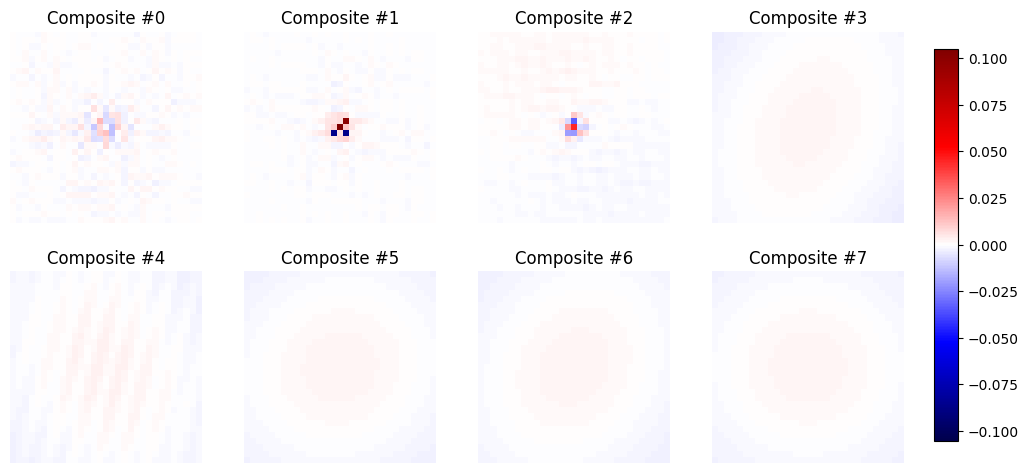

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

k = np.load("results/exp_022/composite_kernels.npy").astype(np.float32)  # (N,H,W)

n = k.shape[0]
cols = min(4, n)
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(3.0 * cols, 2.8 * rows))
axes = np.array(axes).reshape(rows, cols)

vmax = np.max(np.abs(k)) + 1e-12
im = None
for i in range(rows * cols):
    ax = axes.flat[i]
    if i < n:
        im = ax.imshow(k[i], cmap="seismic", vmin=-vmax, vmax=vmax)
        ax.set_title(f"Composite #{i}")
    ax.axis("off")

# leave room on right side for colorbar
fig.subplots_adjust(right=0.88, wspace=0.15, hspace=0.25)

# colorbar in separate axis (outside images)
cax = fig.add_axes([0.90, 0.15, 0.02, 0.70])  # [left, bottom, width, height]
fig.colorbar(im, cax=cax)

plt.show()


heatmap side by side

In [ ]:
from pathlib import Path
import re
from PIL import Image

exp_dir = Path("results/exp_022_mmr_nperFamily500_nComposition1250")
heatmaps_dir = exp_dir / "heatmaps"
pair_dir = exp_dir / "heatmaps_pairs"
pair_dir.mkdir(exist_ok=True)

normal_dir = Path("data/TIFF Images/Normal")
mal_ann_dir = Path("data/TIFF Images/malignantAnnotation")
mal_dir = Path("data/TIFF Images/Malignant")

img_pat = re.compile(r"(IMG\d+)", re.IGNORECASE)

max_side = 512

if not heatmaps_dir.exists():
    raise RuntimeError(f"Heatmaps folder not found: {heatmaps_dir}")

heatmaps = [p for p in heatmaps_dir.iterdir() if p.suffix.lower() in {".png", ".jpg", ".jpeg"}]
print("Example heatmap filenames:", [p.name for p in heatmaps[:5]])


def find_original(img_id: str) -> Path | None:
    # try exact and any extension, then case variants
    for d in (normal_dir, mal_ann_dir, mal_dir):
        for p in d.glob(f"{img_id}.*"):
            return p
        for p in d.glob(f"{img_id.lower()}.*"):
            return p
        for p in d.glob(f"{img_id.upper()}.*"):
            return p
    return None


normals = []
mals = []
missing = []

for hm in sorted(heatmaps):
    m = img_pat.search(hm.name)
    if not m:
        continue
    img_id = m.group(1)
    orig_path = find_original(img_id)
    if orig_path is None:
        missing.append(img_id)
        continue
    if orig_path.parent == normal_dir:
        normals.append((img_id, hm, orig_path))
    else:
        mals.append((img_id, hm, orig_path))

normals = normals[:2]
mals = mals[:2]
selected = normals + mals

if missing:
    print("Missing originals for:", sorted(set(missing))[:10])

if not selected:
    raise RuntimeError("No heatmaps found with matching original images.")

pair_images = []
max_h = 0
max_w = 0

for img_id, heatmap_path, orig_path in selected:
    orig = Image.open(orig_path).convert("RGB")
    heat = Image.open(heatmap_path).convert("RGB")

    orig.thumbnail((max_side, max_side), Image.BILINEAR)
    heat.thumbnail((max_side, max_side), Image.BILINEAR)

    if heat.size != orig.size:
        heat = heat.resize(orig.size, Image.BILINEAR)

    w, h = orig.size
    pair = Image.new("RGB", (w * 2, h))
    pair.paste(orig, (0, 0))
    pair.paste(heat, (w, 0))

    pair.save(pair_dir / f"{img_id}_pair.png")
    pair_images.append(pair)
    max_h = max(max_h, h)
    max_w = max(max_w, w * 2)

while len(pair_images) < 4:
    pair_images.append(Image.new("RGB", (max_w, max_h), color=(0, 0, 0)))

resized = []
for im in pair_images[:4]:
    if im.size != (max_w, max_h):
        im = im.resize((max_w, max_h), Image.BILINEAR)
    resized.append(im)

grid = Image.new("RGB", (max_w * 2, max_h * 2))
grid.paste(resized[0], (0, 0))
grid.paste(resized[1], (max_w, 0))
grid.paste(resized[2], (0, max_h))
grid.paste(resized[3], (max_w, max_h))

grid.save(exp_dir / "heatmaps_side_by_side.png")
print("Saved:", exp_dir / "heatmaps_side_by_side.png")


Example heatmap filenames: ['IMG044_kernel_compose_heatmap.png', 'IMG330_kernel_compose_heatmap.png', 'IMG059_kernel_compose_heatmap.png', 'IMG015_kernel_compose_heatmap.png']
Saved: results/exp_022_mmr_nperFamily500_nComposition1250/heatmaps_side_by_side.png
